## Data Preparation

This notebook loads the raw bilingual dataset collected from JAMK's Peppi curriculum system, cleans the text, constructs six experimental text configurations, and applies Finnish and English lemmatization. 

The outputs feed directly into the embedding 
generation step in Notebook 2.

### Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import re
import unicodedata
import spacy
import os

# Load Finnish and English spaCy models
nlp_fi = spacy.load("fi_core_news_sm")
nlp_en = spacy.load("en_core_web_sm")

print("spaCy models loaded successfully")
print(f"Finnish pipeline: {nlp_fi.pipe_names}")
print(f"English pipeline: {nlp_en.pipe_names}")

spaCy models loaded successfully
Finnish pipeline: ['tok2vec', 'tagger', 'morphologizer', 'parser', 'lemmatizer', 'attribute_ruler', 'ner']
English pipeline: ['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']


### Loading the Dataset

The raw dataset contains 154 manually labelled bilingual course description pairs 
collected from JAMK's ICT degree programme. 

Each pair carries a binary similarity 
label: 1 for equivalent and 0 for non-equivalent.

In [2]:
base = r"C:\Users\madee\OneDrive\Desktop\thesis\Thesis Project - Final"

df = pd.read_csv(os.path.join(base, "data", "final_dataset.csv"))

print(f"Shape: {df.shape}")
print(f"\nColumns:\n{df.columns.tolist()}")
print(f"\nLabel distribution:\n{df['similarity_label'].value_counts()}")

Shape: (154, 15)

Columns:
['course_id', 'title_fi', 'title_en', 'credits', 'outcomes_fi', 'outcomes_en', 'contents_fi', 'contents_en', 'assessment_fi', 'assessment_en', 'similarity_label', 'label_note', 'label_timestamp', 'pair_type', 'pair_difficulty']

Label distribution:
similarity_label
1    77
0    77
Name: count, dtype: int64


### A Closer Look at the Data

Before any processing begins, it is worth seeing what the raw pairs actually look like. 

The two examples below show one equivalent pair and one non-equivalent pair from the dataset, giving a concrete sense of what the model will later need to distinguish.

In [3]:
for label in [1, 0]:
    sample = df[df['similarity_label'] == label].iloc[0]
    print(f"Label: {label}")
    print(f"Course ID: {sample['course_id']}")
    print(f"Finnish outcomes: {sample['outcomes_fi'][:300]}")
    print(f"English outcomes: {sample['outcomes_en'][:300]}")
    print("-" * 80)

Label: 1
Course ID: TT00CE07
Finnish outcomes: Opiskelija ymmärtää kyberturvallisuuden ja tietoturvallisuuden hallintajärjestelmien merkityksen, periaatteet ja vaatimukset organisaatioissa ja yhteiskunnassa. Opiskelija tuntee ISO/IEC 27000 -standardisarjan sisällön, rakenteen ja soveltamisalan sekä osaa hyödyntää sitä kyberturvallisuuden hallinn
English outcomes: The student understands the importance, principles and requirements of cyber security and information security management systems in organizations and society. The student knows the content, structure and scope of the ISO/IEC 27000 series of standards and its use in the planning, implementation and 
--------------------------------------------------------------------------------
Label: 0
Course ID: SYN_HARD_TT00CD89_TT00CD82
Finnish outcomes: Opintojakson suoritettuasi ymmärrät ohjelmistojen laadunvarmistuksen ja testauksen merkityksen osana ohjelmistotuotannon prosessia. Tunnet ohjelmistotestauksen tärkeät käsitteet, kuten yk

### Cleaning the Text Fields

The scraped text contains several artifacts introduced during data collection: bullet point characters, combining diacritics attached to letters, and stray whitespace. 

These are removed here before any configuration or lemmatization is applied. 

Missing values in text fields are filled with empty strings to prevent downstream errors.

In [4]:
text_columns = [
    'outcomes_fi', 'outcomes_en',
    'contents_fi', 'contents_en',
    'assessment_fi', 'assessment_en'
]

def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.strip()
    # Remove bullet point artifacts
    text = re.sub(r'[\u2022\u2023\u25E6\u2043\u2219]', '', text)
    # Recompose characters using NFC to resolve diacritic artifacts 
    # while preserving Finnish characters such as a and o with umlauts
    text = unicodedata.normalize('NFC', text)
    # Normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

for col in text_columns:
    df[col] = df[col].apply(clean_text)

print("Cleaning complete.")
print(f"\nEmpty fields after cleaning:")
for col in text_columns:
    empty = (df[col] == '').sum()
    print(f"  {col}: {empty}")

Cleaning complete.

Empty fields after cleaning:
  outcomes_fi: 0
  outcomes_en: 0
  contents_fi: 0
  contents_en: 0
  assessment_fi: 0
  assessment_en: 0


### Building the Six Text Configurations

Each pair is represented in six ways by combining different fields. 

Configurations 1 to 3 use raw cleaned text. Configurations 4 to 6 repeat the same combinations using lemmatized text, which is produced in the next step. 

This design allows a direct comparison between raw and lemmatized conditions across identical field combinations.

| Config | Fields included                          | Text type   |
|--------|------------------------------------------|-------------|
| 1      | Outcomes                                 | Raw         |
| 2      | Outcomes + Contents                      | Raw         |
| 3      | Outcomes + Contents + Assessment         | Raw         |
| 4      | Outcomes                                 | Lemmatized  |
| 5      | Outcomes + Contents                      | Lemmatized  |
| 6      | Outcomes + Contents + Assessment         | Lemmatized  |

In [5]:
# Build raw configurations
df['config_1_fi'] = df['outcomes_fi']
df['config_1_en'] = df['outcomes_en']

df['config_2_fi'] = df['outcomes_fi'] + ' ' + df['contents_fi']
df['config_2_en'] = df['outcomes_en'] + ' ' + df['contents_en']

df['config_3_fi'] = df['outcomes_fi'] + ' ' + df['contents_fi'] + ' ' + df['assessment_fi']
df['config_3_en'] = df['outcomes_en'] + ' ' + df['contents_en'] + ' ' + df['assessment_en']

print("Raw configurations built.")
print(f"\nConfig 1 sample (Finnish):\n{df['config_1_fi'].iloc[0][:200]}")
print(f"\nConfig 2 sample (Finnish):\n{df['config_2_fi'].iloc[0][:200]}")
print(f"\nConfig 3 sample (Finnish):\n{df['config_3_fi'].iloc[0][:200]}")

Raw configurations built.

Config 1 sample (Finnish):
Opiskelija ymmärtää kyberturvallisuuden ja tietoturvallisuuden hallintajärjestelmien merkityksen, periaatteet ja vaatimukset organisaatioissa ja yhteiskunnassa. Opiskelija tuntee ISO/IEC 27000 -standa

Config 2 sample (Finnish):
Opiskelija ymmärtää kyberturvallisuuden ja tietoturvallisuuden hallintajärjestelmien merkityksen, periaatteet ja vaatimukset organisaatioissa ja yhteiskunnassa. Opiskelija tuntee ISO/IEC 27000 -standa

Config 3 sample (Finnish):
Opiskelija ymmärtää kyberturvallisuuden ja tietoturvallisuuden hallintajärjestelmien merkityksen, periaatteet ja vaatimukset organisaatioissa ja yhteiskunnassa. Opiskelija tuntee ISO/IEC 27000 -standa


### Applying Lemmatization

Finnish is a morphologically rich language where the same word can appear in dozens of inflected forms. 

Lemmatization reduces each word to its base form, which can help embedding models treat inflected variants as the same concept. The Finnish pipeline uses spaCy's fi_core_news_sm model and the English pipeline uses en_core_web_sm. 

Lemmatization is applied to all six text fields before building configurations 4 to 6.

In [6]:
def lemmatize_text(text, nlp):
    if not isinstance(text, str) or text.strip() == "":
        return ""
    doc = nlp(text)
    return ' '.join(token.lemma_ for token in doc if not token.is_space)

print("Lemmatizing Finnish fields...")
for col in ['outcomes_fi', 'contents_fi', 'assessment_fi']:
    df[col + '_lemma'] = df[col].apply(lambda x: lemmatize_text(x, nlp_fi))
    print(f"  {col} done")

print("\nLemmatizing English fields...")
for col in ['outcomes_en', 'contents_en', 'assessment_en']:
    df[col + '_lemma'] = df[col].apply(lambda x: lemmatize_text(x, nlp_en))
    print(f"  {col} done")

print("\nLemmatization complete.")
print(f"\nRaw outcomes sample:\n{df['outcomes_fi'].iloc[0][:200]}")
print(f"\nLemmatized outcomes sample:\n{df['outcomes_fi_lemma'].iloc[0][:200]}")

Lemmatizing Finnish fields...
  outcomes_fi done
  contents_fi done
  assessment_fi done

Lemmatizing English fields...
  outcomes_en done
  contents_en done
  assessment_en done

Lemmatization complete.

Raw outcomes sample:
Opiskelija ymmärtää kyberturvallisuuden ja tietoturvallisuuden hallintajärjestelmien merkityksen, periaatteet ja vaatimukset organisaatioissa ja yhteiskunnassa. Opiskelija tuntee ISO/IEC 27000 -standa

Lemmatized outcomes sample:
opiskelija ymmärtää kyberturvallisuuden ja tietoturvallisuuden hallintajärjestelmä merkitys , periaate ja vaatimus organisaatioi ja yhteiskunta . opiskelija tuntea ISO / IEC 27000 standardisarja sisäl


### Building Lemmatized Configurations

Configurations 4 to 6 mirror the raw configurations exactly, using the same field combinations but with lemmatized text. This produces a clean paired design where the only difference between config 1 and config 4, for example, is whether the text was lemmatized or not.

In [7]:
# Build lemmatized configurations
df['config_4_fi'] = df['outcomes_fi_lemma']
df['config_4_en'] = df['outcomes_en_lemma']

df['config_5_fi'] = df['outcomes_fi_lemma'] + ' ' + df['contents_fi_lemma']
df['config_5_en'] = df['outcomes_en_lemma'] + ' ' + df['contents_en_lemma']

df['config_6_fi'] = df['outcomes_fi_lemma'] + ' ' + df['contents_fi_lemma'] + ' ' + df['assessment_fi_lemma']
df['config_6_en'] = df['outcomes_en_lemma'] + ' ' + df['contents_en_lemma'] + ' ' + df['assessment_en_lemma']

print("Lemmatized configurations built.")
print(f"\nConfig 4 sample (Finnish):\n{df['config_4_fi'].iloc[0][:200]}")
print(f"\nConfig 5 sample (Finnish):\n{df['config_5_fi'].iloc[0][:200]}")
print(f"\nConfig 6 sample (Finnish):\n{df['config_6_fi'].iloc[0][:200]}")


Lemmatized configurations built.

Config 4 sample (Finnish):
opiskelija ymmärtää kyberturvallisuuden ja tietoturvallisuuden hallintajärjestelmä merkitys , periaate ja vaatimus organisaatioi ja yhteiskunta . opiskelija tuntea ISO / IEC 27000 standardisarja sisäl

Config 5 sample (Finnish):
opiskelija ymmärtää kyberturvallisuuden ja tietoturvallisuuden hallintajärjestelmä merkitys , periaate ja vaatimus organisaatioi ja yhteiskunta . opiskelija tuntea ISO / IEC 27000 standardisarja sisäl

Config 6 sample (Finnish):
opiskelija ymmärtää kyberturvallisuuden ja tietoturvallisuuden hallintajärjestelmä merkitys , periaate ja vaatimus organisaatioi ja yhteiskunta . opiskelija tuntea ISO / IEC 27000 standardisarja sisäl



### Verification Checks

Before saving, two checks are run across all twelve configuration columns. The first looks for standalone nan tokens, which can appear when missing fields are concatenated as strings. The second confirms no configuration column is empty for any row. 

Both checks must pass cleanly before the data moves to the next stage.

In [8]:
config_columns = [
    'config_1_fi', 'config_1_en',
    'config_2_fi', 'config_2_en',
    'config_3_fi', 'config_3_en',
    'config_4_fi', 'config_4_en',
    'config_5_fi', 'config_5_en',
    'config_6_fi', 'config_6_en'
]

print("Checking for standalone nan tokens...")
nan_found = False
for col in config_columns:
    matches = df[col].apply(lambda x: bool(re.search(r'\bnan\b', str(x))))
    count = matches.sum()
    if count > 0:
        print(f"  WARNING: {col} has {count} standalone nan token(s)")
        nan_found = True
if not nan_found:
    print("  No standalone nan tokens found.")

print("\nChecking for empty configuration columns...")
empty_found = False
for col in config_columns:
    empty = (df[col].str.strip() == '').sum()
    if empty > 0:
        print(f"  WARNING: {col} has {empty} empty row(s)")
        empty_found = True
if not empty_found:
    print("  No empty configuration columns found.")

print("\nAll checks passed." if not nan_found and not empty_found else "\nIssues found. Fix before saving.")

Checking for standalone nan tokens...
  No standalone nan tokens found.

Checking for empty configuration columns...
  No empty configuration columns found.

All checks passed.


### Text Length Distribution Across Configurations

Longer configurations naturally contain more text, which affects how much information is available to the embedding model. 

The chart below shows the average word count per configuration for Finnish and English separately, giving a quick sense of how much content each configuration carries into the embedding step.

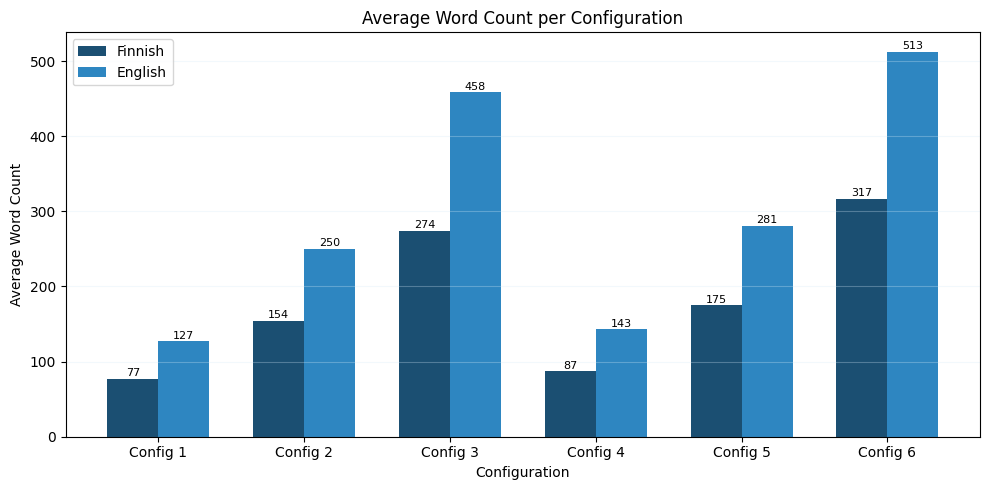

Plot saved.


In [9]:
import matplotlib.pyplot as plt

# Color theme
PRIMARY = '#1B4F72'
SECONDARY = '#2E86C1'

avg_lengths = {}
for i in range(1, 7):
    avg_lengths[f'Config {i} FI'] = df[f'config_{i}_fi'].apply(lambda x: len(x.split())).mean()
    avg_lengths[f'Config {i} EN'] = df[f'config_{i}_en'].apply(lambda x: len(x.split())).mean()

configs = [f'Config {i}' for i in range(1, 7)]
fi_means = [avg_lengths[f'Config {i} FI'] for i in range(1, 7)]
en_means = [avg_lengths[f'Config {i} EN'] for i in range(1, 7)]

x = range(len(configs))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars_fi = ax.bar([i - width/2 for i in x], fi_means, width, label='Finnish', color=PRIMARY)
bars_en = ax.bar([i + width/2 for i in x], en_means, width, label='English', color=SECONDARY)

ax.set_xlabel('Configuration')
ax.set_ylabel('Average Word Count')
ax.set_title('Average Word Count per Configuration')
ax.set_xticks(list(x))
ax.set_xticklabels(configs)
ax.legend()
ax.grid(axis='y', alpha=0.3, color='#D6EAF8')

for bar in bars_fi:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=8)
for bar in bars_en:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{bar.get_height():.0f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(base, "figures", "main", "config_word_counts.png"), dpi=150)
plt.show()
print("Plot saved.")

English descriptions are consistently longer than Finnish across all configurations, reflecting Finnish morphological density where inflected forms compress meaning into fewer words. 

Word count grows steadily as more fields are added, with configurations 3 and 6 averaging over 450 words in English, well above the 512-token limit of most transformer models. 

This length characteristic is examined in detail during the extended analysis in Notebook 5.

### Saving the Preprocessed Dataset

The cleaned and configured dataset is saved to the processed data folder. This file serves as the single input to Notebook 2, ensuring that embedding generation always starts from the same verified and reproducible state.

In [10]:
import os

output_dir = r"C:\Users\madee\OneDrive\Desktop\thesis\Thesis Project - Final\data\processed"
os.makedirs(output_dir, exist_ok=True)

output_path = os.path.join(output_dir, "dataset_preprocessed.csv")
df.to_csv(output_path, index=False)

print(f"Dataset saved to: {output_path}")
print(f"Shape: {df.shape}")
print(f"\nColumns saved:\n{df.columns.tolist()}")

Dataset saved to: C:\Users\madee\OneDrive\Desktop\thesis\Thesis Project - Final\data\processed\dataset_preprocessed.csv
Shape: (154, 33)

Columns saved:
['course_id', 'title_fi', 'title_en', 'credits', 'outcomes_fi', 'outcomes_en', 'contents_fi', 'contents_en', 'assessment_fi', 'assessment_en', 'similarity_label', 'label_note', 'label_timestamp', 'pair_type', 'pair_difficulty', 'config_1_fi', 'config_1_en', 'config_2_fi', 'config_2_en', 'config_3_fi', 'config_3_en', 'outcomes_fi_lemma', 'contents_fi_lemma', 'assessment_fi_lemma', 'outcomes_en_lemma', 'contents_en_lemma', 'assessment_en_lemma', 'config_4_fi', 'config_4_en', 'config_5_fi', 'config_5_en', 'config_6_fi', 'config_6_en']


### Summary

This notebook produced a fully cleaned and configured dataset ready for embedding generation. 

Starting from 154 raw bilingual course description pairs, the pipeline removed scraper artifacts, applied NFC normalization to preserve Finnish characters, built six text configurations combining outcomes, contents, and assessment fields, and applied spaCy lemmatization for both Finnish and English. 

All verification checks passed with no empty fields and no standalone nan tokens. 

The preprocessed dataset containing all 12 configuration columns has been saved to data/processed/dataset_preprocessed.csv and serves as the sole input to Notebook 2.